# Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

### **Problem Statement**
Develop and compare **Simple RNN, LSTM, and GRU** models for **next-word prediction and text generation** using a custom text corpus. The objective is to identify which recurrent architecture generates the most coherent text while achieving the best generalization performance.


The project compares **Simple RNN, LSTM, and GRU** using the same dataset and training setup, followed by model optimization through validation, hyperparameter tuning, and early stopping to determine the best-performing architecture.

## 1. Library Import & Environment Setup

In [1]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.facecolor"] = "white"
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None

print(f"TensorFlow version : {tf.__version__}")

TensorFlow version : 2.20.0


## 2. Load Text Corpus

In [2]:
corpus_text='''Artificial intelligence is transforming the way organizations solve complex problems.
Artificial intelligence helps teams make better decisions using large amounts of data.
Artificial intelligence continues to evolve as new research and tools become available.
Artificial intelligence plays an important role in modern software development practices.
Artificial intelligence requires careful planning, testing, and continuous improvement over time.
Artificial intelligence enables systems to adapt quickly to changing real world conditions.
Artificial intelligence reduces manual effort by automating repetitive and time consuming tasks.
Artificial intelligence supports innovation across healthcare, finance, and other major industries.
Artificial intelligence relies on high quality data to produce reliable and accurate results.
Artificial intelligence improves efficiency while lowering the overall cost of operations.
Machine learning is transforming the way organizations solve complex problems.
Machine learning helps teams make better decisions using large amounts of data.
Machine learning continues to evolve as new research and tools become available.
Machine learning plays an important role in modern software development practices.
Machine learning requires careful planning, testing, and continuous improvement over time.
Machine learning enables systems to adapt quickly to changing real world conditions.
Machine learning reduces manual effort by automating repetitive and time consuming tasks.
Machine learning supports innovation across healthcare, finance, and other major industries.
Machine learning relies on high quality data to produce reliable and accurate results.
Machine learning improves efficiency while lowering the overall cost of operations.
Deep learning is transforming the way organizations solve complex problems.
Deep learning helps teams make better decisions using large amounts of data.
Deep learning continues to evolve as new research and tools become available.
Deep learning plays an important role in modern software development practices.
Deep learning requires careful planning, testing, and continuous improvement over time.
Deep learning enables systems to adapt quickly to changing real world conditions.
Deep learning reduces manual effort by automating repetitive and time consuming tasks.
Deep learning supports innovation across healthcare, finance, and other major industries.
Deep learning relies on high quality data to produce reliable and accurate results.
Deep learning improves efficiency while lowering the overall cost of operations.
Natural language processing is transforming the way organizations solve complex problems.
Natural language processing helps teams make better decisions using large amounts of data.
Natural language processing continues to evolve as new research and tools become available.
Natural language processing plays an important role in modern software development practices.
Natural language processing requires careful planning, testing, and continuous improvement over time.
Natural language processing enables systems to adapt quickly to changing real world conditions.
Natural language processing reduces manual effort by automating repetitive and time consuming tasks.
Natural language processing supports innovation across healthcare, finance, and other major industries.
Natural language processing relies on high quality data to produce reliable and accurate results.
Natural language processing improves efficiency while lowering the overall cost of operations.
Computer vision is transforming the way organizations solve complex problems.
Computer vision helps teams make better decisions using large amounts of data.
Computer vision continues to evolve as new research and tools become available.
Computer vision plays an important role in modern software development practices.
Computer vision requires careful planning, testing, and continuous improvement over time.
Computer vision enables systems to adapt quickly to changing real world conditions.
Computer vision reduces manual effort by automating repetitive and time consuming tasks.
Computer vision supports innovation across healthcare, finance, and other major industries.
Computer vision relies on high quality data to produce reliable and accurate results.
Computer vision improves efficiency while lowering the overall cost of operations.
Robotics is transforming the way organizations solve complex problems.
Robotics helps teams make better decisions using large amounts of data.
Robotics continues to evolve as new research and tools become available.
Robotics plays an important role in modern software development practices.
Robotics requires careful planning, testing, and continuous improvement over time.
Robotics enables systems to adapt quickly to changing real world conditions.
Robotics reduces manual effort by automating repetitive and time consuming tasks.
Robotics supports innovation across healthcare, finance, and other major industries.
Robotics relies on high quality data to produce reliable and accurate results.
Robotics improves efficiency while lowering the overall cost of operations.
Cloud computing is transforming the way organizations solve complex problems.
Cloud computing helps teams make better decisions using large amounts of data.
Cloud computing continues to evolve as new research and tools become available.
Cloud computing plays an important role in modern software development practices.
Cloud computing requires careful planning, testing, and continuous improvement over time.
Cloud computing enables systems to adapt quickly to changing real world conditions.
Cloud computing reduces manual effort by automating repetitive and time consuming tasks.
Cloud computing supports innovation across healthcare, finance, and other major industries.
Cloud computing relies on high quality data to produce reliable and accurate results.
Cloud computing improves efficiency while lowering the overall cost of operations.
Data engineering is transforming the way organizations solve complex problems.
Data engineering helps teams make better decisions using large amounts of data.
Data engineering continues to evolve as new research and tools become available.
Data engineering plays an important role in modern software development practices.
Data engineering requires careful planning, testing, and continuous improvement over time.
Data engineering enables systems to adapt quickly to changing real world conditions.
Data engineering reduces manual effort by automating repetitive and time consuming tasks.
Data engineering supports innovation across healthcare, finance, and other major industries.
Data engineering relies on high quality data to produce reliable and accurate results.
Data engineering improves efficiency while lowering the overall cost of operations.
Cybersecurity is transforming the way organizations solve complex problems.
Cybersecurity helps teams make better decisions using large amounts of data.
Cybersecurity continues to evolve as new research and tools become available.
Cybersecurity plays an important role in modern software development practices.
Cybersecurity requires careful planning, testing, and continuous improvement over time.
Cybersecurity enables systems to adapt quickly to changing real world conditions.
Cybersecurity reduces manual effort by automating repetitive and time consuming tasks.
Cybersecurity supports innovation across healthcare, finance, and other major industries.
Cybersecurity relies on high quality data to produce reliable and accurate results.
Cybersecurity improves efficiency while lowering the overall cost of operations.
Reinforcement learning is transforming the way organizations solve complex problems.
Reinforcement learning helps teams make better decisions using large amounts of data.
Reinforcement learning continues to evolve as new research and tools become available.
Reinforcement learning plays an important role in modern software development practices.
Reinforcement learning requires careful planning, testing, and continuous improvement over time.
Reinforcement learning enables systems to adapt quickly to changing real world conditions.
Reinforcement learning reduces manual effort by automating repetitive and time consuming tasks.
Reinforcement learning supports innovation across healthcare, finance, and other major industries.
Reinforcement learning relies on high quality data to produce reliable and accurate results.
Reinforcement learning improves efficiency while lowering the overall cost of operations.
Generative modeling is transforming the way organizations solve complex problems.
Generative modeling helps teams make better decisions using large amounts of data.
Generative modeling continues to evolve as new research and tools become available.
Generative modeling plays an important role in modern software development practices.
Generative modeling requires careful planning, testing, and continuous improvement over time.
Generative modeling enables systems to adapt quickly to changing real world conditions.
Generative modeling reduces manual effort by automating repetitive and time consuming tasks.
Generative modeling supports innovation across healthcare, finance, and other major industries.
Generative modeling relies on high quality data to produce reliable and accurate results.
Generative modeling improves efficiency while lowering the overall cost of operations.
Time series analysis is transforming the way organizations solve complex problems.
Time series analysis helps teams make better decisions using large amounts of data.
Time series analysis continues to evolve as new research and tools become available.
Time series analysis plays an important role in modern software development practices.
Time series analysis requires careful planning, testing, and continuous improvement over time.
Time series analysis enables systems to adapt quickly to changing real world conditions.
Time series analysis reduces manual effort by automating repetitive and time consuming tasks.
Time series analysis supports innovation across healthcare, finance, and other major industries.
Time series analysis relies on high quality data to produce reliable and accurate results.
Time series analysis improves efficiency while lowering the overall cost of operations.
Big data analytics is transforming the way organizations solve complex problems.
Big data analytics helps teams make better decisions using large amounts of data.
Big data analytics continues to evolve as new research and tools become available.
Big data analytics plays an important role in modern software development practices.
Big data analytics requires careful planning, testing, and continuous improvement over time.
Big data analytics enables systems to adapt quickly to changing real world conditions.
Big data analytics reduces manual effort by automating repetitive and time consuming tasks.
Big data analytics supports innovation across healthcare, finance, and other major industries.
Big data analytics relies on high quality data to produce reliable and accurate results.
Big data analytics improves efficiency while lowering the overall cost of operations.
Edge computing is transforming the way organizations solve complex problems.
Edge computing helps teams make better decisions using large amounts of data.
Edge computing continues to evolve as new research and tools become available.
Edge computing plays an important role in modern software development practices.
Edge computing requires careful planning, testing, and continuous improvement over time.
Edge computing enables systems to adapt quickly to changing real world conditions.
Edge computing reduces manual effort by automating repetitive and time consuming tasks.
Edge computing supports innovation across healthcare, finance, and other major industries.
Edge computing relies on high quality data to produce reliable and accurate results.
Edge computing improves efficiency while lowering the overall cost of operations.
Predictive analytics is transforming the way organizations solve complex problems.
Predictive analytics helps teams make better decisions using large amounts of data.
Predictive analytics continues to evolve as new research and tools become available.
Predictive analytics plays an important role in modern software development practices.
Predictive analytics requires careful planning, testing, and continuous improvement over time.
Predictive analytics enables systems to adapt quickly to changing real world conditions.
Predictive analytics reduces manual effort by automating repetitive and time consuming tasks.
Predictive analytics supports innovation across healthcare, finance, and other major industries.
Predictive analytics relies on high quality data to produce reliable and accurate results.
Predictive analytics improves efficiency while lowering the overall cost of operations.
Data science is transforming the way organizations solve complex problems.
Data science helps teams make better decisions using large amounts of data.
Data science continues to evolve as new research and tools become available.
Data science plays an important role in modern software development practices.
Data science requires careful planning, testing, and continuous improvement over time.
Data science enables systems to adapt quickly to changing real world conditions.
Data science reduces manual effort by automating repetitive and time consuming tasks.
Data science supports innovation across healthcare, finance, and other major industries.
Data science relies on high quality data to produce reliable and accurate results.
Data science improves efficiency while lowering the overall cost of operations.
Neural networks is transforming the way organizations solve complex problems.
Neural networks helps teams make better decisions using large amounts of data.
Neural networks continues to evolve as new research and tools become available.
Neural networks plays an important role in modern software development practices.
Neural networks requires careful planning, testing, and continuous improvement over time.
Neural networks enables systems to adapt quickly to changing real world conditions.
Neural networks reduces manual effort by automating repetitive and time consuming tasks.
Neural networks supports innovation across healthcare, finance, and other major industries.
Neural networks relies on high quality data to produce reliable and accurate results.
Neural networks improves efficiency while lowering the overall cost of operations.
Autonomous systems is transforming the way organizations solve complex problems.
Autonomous systems helps teams make better decisions using large amounts of data.
Autonomous systems continues to evolve as new research and tools become available.
Autonomous systems plays an important role in modern software development practices.
Autonomous systems requires careful planning, testing, and continuous improvement over time.
Autonomous systems enables systems to adapt quickly to changing real world conditions.
Autonomous systems reduces manual effort by automating repetitive and time consuming tasks.
Autonomous systems supports innovation across healthcare, finance, and other major industries.
Autonomous systems relies on high quality data to produce reliable and accurate results.
Autonomous systems improves efficiency while lowering the overall cost of operations.'''

## 3. Corpus Overview
- Split the corpus into clean sentences (one document per line).
- Check for exact duplicate sentences to ensure data quality before train–validation splitting.
- Verify that unique sentence count equals the total sentence count.

In [3]:
lines = [l.strip() for l in corpus_text.strip().split("\n") if l.strip()]
print(f"Number of sentences (documents): {len(lines)}")
print(f"Average sentence length (words): {np.mean([len(l.split()) for l in lines]):.1f}")
print("\nSample sentences:")
for s in lines[:3]:
    print(" -", s)
n_unique = len(set(lines))
print(f"Unique sentences: {n_unique} / {len(lines)} total  ->  {'OK, no duplicates' if n_unique == len(lines) else 'WARNING: duplicates found'}")


Number of sentences (documents): 180
Average sentence length (words): 11.6

Sample sentences:
 - Artificial intelligence is transforming the way organizations solve complex problems.
 - Artificial intelligence helps teams make better decisions using large amounts of data.
 - Artificial intelligence continues to evolve as new research and tools become available.
Unique sentences: 180 / 180 total  ->  OK, no duplicates


**Observation:**
- The corpus contains 180 unique sentences with an average length of 11.6 words, indicating a concise and consistent dataset.
- The duplicate check confirms that all sentences are unique, ensuring good data quality for model training.

## 4. Text Preprocessing & Sequence Generation

- **Word-level tokenization:** Converts words into integer IDs, creating a clean vocabulary for next-word prediction.
- **Sliding window sequences:** Generates multiple input–output pairs from each sentence, increasing training samples and helping the model learn next-word prediction.
- **Pre-padding:** Pads shorter sequences at the beginning so all inputs have the same length while preserving the most recent context.

In [4]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(lines)

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size (including OOV & padding): {vocab_size}")

input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[: i + 1])

max_seq_len = max(len(seq) for seq in input_sequences)
print(f"Total training sequences generated: {len(input_sequences)}")
print(f"Longest sequence (tokens): {max_seq_len}")

padded_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding="pre")

X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")


Vocabulary size (including OOV & padding): 114
Total training sequences generated: 1900
Longest sequence (tokens): 14
X shape: (1900, 13)  |  y shape: (1900,)


**Observation:**
- A vocabulary of 114 tokens was created, and 1,900 training sequences were generated from the corpus.
- The maximum sequence length is 14 tokens, resulting in input data of shape (1900, 13) and target labels of shape (1900,)

In [5]:
# Create an index-to-word mapping and check a sample sequence to ensure that the sliding window
# preprocessing correctly generates context words and their corresponding next-word targets.
idx2word = {v: k for k, v in tokenizer.word_index.items()}
idx2word[0] = "<PAD>"

sample_i = 25
context_words = [idx2word[t] for t in X[sample_i] if t != 0]
print("Context :", " ".join(context_words))
print("Target  :", idx2word[y[sample_i]])


Context : artificial intelligence continues to evolve as
Target  : new


## 5. Baseline Text Generation Models Training (100 Epochs)

A baseline experiment is performed before optimization to establish reference performance.

- **Model comparison:** SimpleRNN, LSTM, and GRU are trained with the same settings for a fair comparison.
- **100 epochs:** Used as a fixed training duration as required for baseline evaluation.
- **Loss curves:** Plotted to compare convergence and training behavior of different architectures.

In [6]:
BASELINE_EMBEDDING_DIM = 32
BASELINE_RNN_UNITS = 64
BASELINE_EPOCHS = 100
BASELINE_INPUT_LEN = X.shape[1]

def build_baseline_model(cell_type: str) -> Sequential:
    '''Builds a simple next-word-prediction baseline model using the requested recurrent cell.'''
    cell_map = {"RNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}
    RecurrentLayer = cell_map[cell_type]

    model = Sequential(name=f"{cell_type}_baseline")
    model.add(Embedding(input_dim=vocab_size, output_dim=BASELINE_EMBEDDING_DIM, input_length=BASELINE_INPUT_LEN))
    model.add(RecurrentLayer(BASELINE_RNN_UNITS))
    model.add(Dense(vocab_size, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )
    return model


rnn_model = build_baseline_model("RNN")
rnn_history = rnn_model.fit(X, y, epochs=BASELINE_EPOCHS, verbose=0)
print("Vanilla RNN baseline training completed")

lstm_model = build_baseline_model("LSTM")
lstm_history = lstm_model.fit(X, y, epochs=BASELINE_EPOCHS, verbose=0)
print("LSTM baseline training completed")

gru_model = build_baseline_model("GRU")
gru_history = gru_model.fit(X, y, epochs=BASELINE_EPOCHS, verbose=0)
print("GRU baseline training completed")

Vanilla RNN baseline training completed
LSTM baseline training completed
GRU baseline training completed


## 5.1. Compare Training Loss

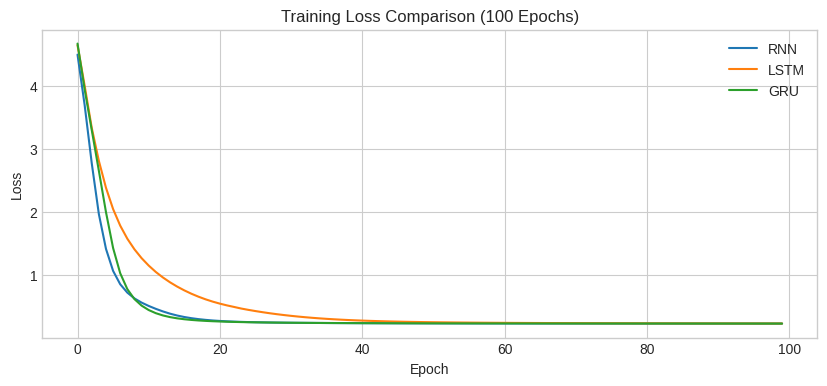

In [7]:
plt.figure(figsize=(10, 4))

plt.plot(rnn_history.history["loss"], label="RNN")
plt.plot(lstm_history.history["loss"], label="LSTM")
plt.plot(gru_history.history["loss"], label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (100 Epochs)")
plt.legend()
plt.show()

**Observation:**
- Training loss decreases rapidly for all models and stabilizes over time.
- RNN and GRU converge faster than LSTM.
- LSTM shows a slower decline in loss but reaches a similar final value.
- All models achieve low and stable training loss

In [8]:
print("\n" + "=" * 60)
print(f"{'Model':<8}{'Loss':<15}{'Accuracy':<18}")
print("-" * 60)
for name, history in [("RNN", rnn_history), ("LSTM", lstm_history), ("GRU", gru_history)]:
    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f"{name:<8}{final_loss:<15.4f}{final_acc:<18.4f}")
print("=" * 60)


Model   Loss           Accuracy          
------------------------------------------------------------
RNN     0.2305         0.9016            
LSTM    0.2318         0.9032            
GRU     0.2306         0.9026            


## 5.2. Baseline Text Generation

A quick generation test is performed to compare baseline model outputs.

- The same seed phrase is used for RNN, LSTM, and GRU for a fair comparison.
- Greedy decoding (np.argmax) selects the next predicted word.
- Short outputs are generated for initial model evaluation.

In [9]:
def generate_text_baseline(model, seed_text: str, next_words: int = 6) -> str:
    '''Greedy (argmax) text generation used for the baseline model comparison.'''
    text = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=BASELINE_INPUT_LEN, padding="pre")
        probs = model.predict(token_list, verbose=0)[0]
        next_index = int(np.argmax(probs))
        next_word = idx2word.get(next_index, "")
        if not next_word or next_word == "<PAD>":
            break
        text += " " + next_word
    return text


baseline_seed = "deep learning is transforming"
print("Baseline greedy text generation (100-epoch models)")
print("-" * 70)
for cell_type, model in [("RNN", rnn_model), ("LSTM", lstm_model), ("GRU", gru_model)]:
    print(f"{cell_type:>4}:", generate_text_baseline(model, baseline_seed))

Baseline greedy text generation (100-epoch models)
----------------------------------------------------------------------
 RNN: deep learning is transforming the way organizations solve complex problems
LSTM: deep learning is transforming the way organizations solve complex problems
 GRU: deep learning is transforming the way organizations solve complex problems


# 6. Final Optimized Model Training with Validation and Hyperparameter Tuning (200 Epochs)


The optimized model is trained to improve baseline performance and ensure better generalization.

- **Validation split:** Separates training and unseen data performance, helping identify overfitting.
- **Hyperparameter tuning:** Finds better model settings to improve learning and prediction accuracy.
- **Increase embedding size and hidden units:** Provides more capacity to capture complex word relationships and sequence patterns.
- **EarlyStopping:** Prevents unnecessary training and overfitting by keeping the best validation-performing weights.
- **200 epochs:** Allows the model enough training time to learn patterns while using validation monitoring for control.

## 6.1. Train - Validation Split

- **Random train–validation split:** Uses train_test_split with shuffling to create representative training and validation sets.
- **85/15 split:** Keeps most data for training while reserving enough samples to reliably evaluate model performance.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)

print(f"Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/len(X):.1%})")
print(f"Validation samples: {X_val.shape[0]}  ({X_val.shape[0]/len(X):.1%})")


Training samples  : 1615  (85.0%)
Validation samples: 285  (15.0%)


## 6.2. Hyperparameter Selection

The hyperparameters were chosen to balance model capacity, training efficiency, and generalization for this small language modeling dataset.

- **Embedding:** 64 dimensions for compact word representations.
- **Recurrent units:** 128 units to capture sequence context.
- **Dropout:** 0.3 to reduce overfitting.
- **Optimizer:** Adam (learning rate = 0.001) for stable convergence.
- **Loss:** Sparse categorical cross-entropy for efficient multi-class prediction.
- **Batch size:** 32 for efficient training.
- **Epochs:** Up to 200 with **Early Stopping**.
- **Regularization:** Early stopping and learning rate reduction improve generalization and prevent overfitting.

In [11]:
EMBEDDING_DIM = 64
RNN_UNITS = 128
DROPOUT_RATE = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 15
INPUT_LEN = X.shape[1]

HYPERPARAMS = dict(
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    dropout=DROPOUT_RATE,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    input_len=INPUT_LEN,
    vocab_size=vocab_size,
)
HYPERPARAMS


{'embedding_dim': 64,
 'rnn_units': 128,
 'dropout': 0.3,
 'lr': 0.001,
 'batch_size': 32,
 'max_epochs': 200,
 'patience': 15,
 'input_len': 13,
 'vocab_size': 114}

## 6.3. Model Architectures: RNN, LSTM, and GRU

Three recurrent models are compared using the **same embedding size, hidden units, dropout, and output layer** to ensure a fair comparison.

- **RNN:** Simple and fast, suitable for short sequences.
- **LSTM:** Uses memory cells and gates to capture long-term dependencies.
- **GRU:** A simpler alternative to LSTM with fewer parameters and faster training.
- **Dropout:** Applied after the recurrent layer to reduce overfitting while maintaining efficient training.

In [12]:
def build_model(cell_type: str) -> Sequential:
    '''Builds a next-word-prediction model using the requested recurrent cell.

    Parameters
    ----------
    cell_type : {"RNN", "LSTM", "GRU"}
    '''
    cell_map = {"RNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}
    RecurrentLayer = cell_map[cell_type]

    model = Sequential(name=f"{cell_type}_text_generator")
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=INPUT_LEN))
    model.add(RecurrentLayer(RNN_UNITS))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(vocab_size, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=LEARNING_RATE),
        metrics=["accuracy"],
    )
    return model

## 6.4. Training with Early Stopping

The models are trained using the same callbacks.

- **Early Stopping:** Stops training when validation loss stops improving and restores the best weights (kept in memory, without saving the model to disk).
- **ReduceLROnPlateau:** Lowers the learning rate when validation loss plateaus to improve convergence.

In [13]:
def get_callbacks(cell_type: str):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_lr=1e-6,
            verbose=0,
        ),
    ]

results = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n{'='*60}\nTraining {cell_type}\n{'='*60}")
    tf.random.set_seed(SEED)
    model = build_model(cell_type)

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(cell_type),
        verbose=2,
    )
    elapsed = time.time() - start

    results[cell_type] = {
        "model": model,
        "history": history,
        "train_time": elapsed,
        "epochs_trained": len(history.history["loss"]),
    }
    print(f"{cell_type} finished in {elapsed:.1f}s "
          f"after {len(history.history['loss'])} epochs "
          f"(early stopping patience={EARLY_STOPPING_PATIENCE}).")



Training RNN
Epoch 1/200
51/51 - 3s - 61ms/step - accuracy: 0.1059 - loss: 4.3820 - val_accuracy: 0.1544 - val_loss: 3.9124 - learning_rate: 0.0010
Epoch 2/200
51/51 - 0s - 8ms/step - accuracy: 0.3591 - loss: 3.2730 - val_accuracy: 0.5825 - val_loss: 2.7654 - learning_rate: 0.0010
Epoch 3/200
51/51 - 0s - 8ms/step - accuracy: 0.6427 - loss: 2.1770 - val_accuracy: 0.6667 - val_loss: 1.8766 - learning_rate: 0.0010
Epoch 4/200
51/51 - 0s - 9ms/step - accuracy: 0.7511 - loss: 1.4709 - val_accuracy: 0.7930 - val_loss: 1.2958 - learning_rate: 0.0010
Epoch 5/200
51/51 - 0s - 8ms/step - accuracy: 0.8062 - loss: 1.0789 - val_accuracy: 0.8070 - val_loss: 1.0000 - learning_rate: 0.0010
Epoch 6/200
51/51 - 0s - 8ms/step - accuracy: 0.8254 - loss: 0.8583 - val_accuracy: 0.8070 - val_loss: 0.8136 - learning_rate: 0.0010
Epoch 7/200
51/51 - 0s - 8ms/step - accuracy: 0.8291 - loss: 0.7239 - val_accuracy: 0.8211 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 8/200
51/51 - 0s - 8ms/step - accuracy: 0

## 6.5. Model Evaluation & Comparison

- **Validation loss & accuracy:** Measure how well the model generalizes to unseen data.
- **Perplexity:** Indicates the model's confidence in predicting the next word (lower is better).
- **Training time:** Evaluates computational efficiency.
- **Best model:** Selected based on the **lowest validation loss**.

In [14]:
comparison_rows = []
for cell_type, res in results.items():
    h = res["history"].history
    val_loss = min(h["val_loss"])
    best_epoch = int(np.argmin(h["val_loss"]))
    val_acc = h["val_accuracy"][best_epoch]
    train_loss = h["loss"][best_epoch]
    train_acc = h["accuracy"][best_epoch]
    perplexity = float(np.exp(val_loss))
    n_params = res["model"].count_params()

    comparison_rows.append({
        "Model": cell_type,
        "Best Epoch": best_epoch + 1,
        "Epochs Trained": res["epochs_trained"],
        "Train Loss": round(train_loss, 4),
        "Train Acc": round(train_acc, 4),
        "Val Loss": round(val_loss, 4),
        "Val Acc": round(val_acc, 4),
        "Val Perplexity": round(perplexity, 2),
        "Params": n_params,
        "Train Time (s)": round(res["train_time"], 1),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df.sort_values("Val Loss")


,Best Epoch,Epochs Trained,Train Loss,Train Acc,Val Loss,Val Acc,Val Perplexity,Params,Train Time (s)
Model,,,,,,,,,
LSTM,39,54,0.2558,0.9053,0.2883,0.8912,1.33,120818,66.3
GRU,18,33,0.2563,0.9108,0.3007,0.8912,1.35,96498,39.6
RNN,23,38,0.2562,0.9096,0.3103,0.8912,1.36,46706,21.0


**Observation:**

- LSTM achieved the lowest validation loss (0.2883), making it the best-performing model.
- GRU provided a good balance between accuracy, parameters, and training time.
- RNN was the fastest model but showed comparatively higher validation loss.
- All models show good generalization with no significant overfitting.

## 6.6. Model Training Performance Analysis

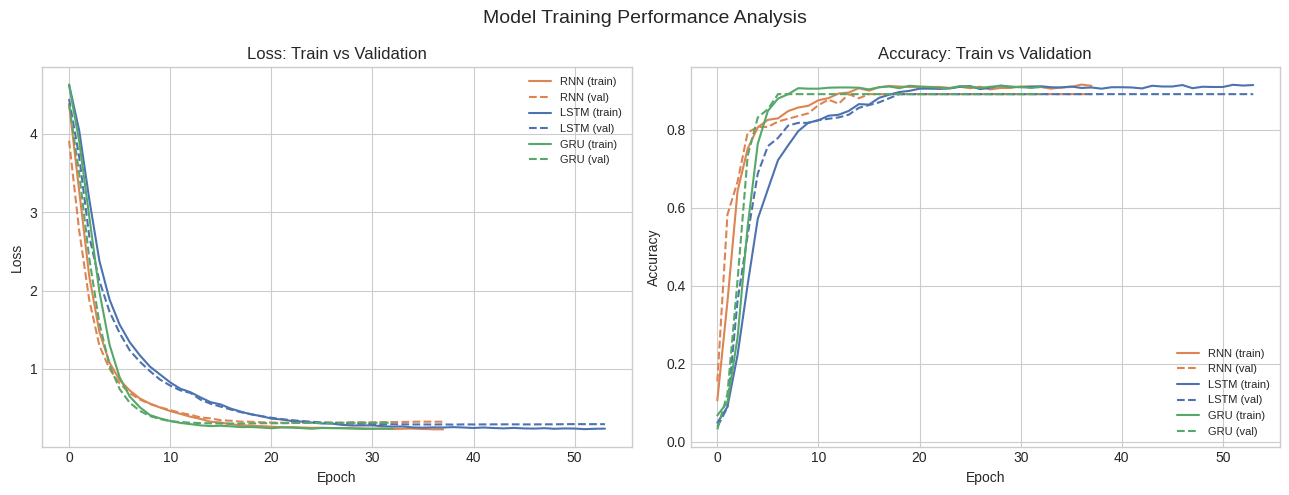

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"RNN": "#DD8452", "LSTM": "#4C72B0", "GRU": "#55A868"}
for cell_type, res in results.items():
    h = res["history"].history
    axes[0].plot(h["loss"], label=f"{cell_type} (train)", color=colors[cell_type])
    axes[0].plot(h["val_loss"], "--", label=f"{cell_type} (val)", color=colors[cell_type])

axes[0].set_title("Loss: Train vs Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)


for cell_type, res in results.items():
    h = res["history"].history
    axes[1].plot(h["accuracy"], label=f"{cell_type} (train)", color=colors[cell_type])
    axes[1].plot(h["val_accuracy"], "--", label=f"{cell_type} (val)", color=colors[cell_type])

axes[1].set_title("Accuracy: Train vs Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)

plt.suptitle("Model Training Performance Analysis", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
best_model_name = comparison_df["Val Loss"].idxmin()
print(f"Selected best model based on lowest validation loss: {best_model_name}")
comparison_df.loc[[best_model_name]]


Selected best model based on lowest validation loss: LSTM


,Best Epoch,Epochs Trained,Train Loss,Train Acc,Val Loss,Val Acc,Val Perplexity,Params,Train Time (s)
Model,,,,,,,,,
LSTM,39,54,0.2558,0.9053,0.2883,0.8912,1.33,120818,66.3


**Observation:**

- LSTM was selected as the best model based on the lowest validation loss (0.2883).
- The model achieved 90.53% training accuracy and 89.12% validation accuracy, showing good generalization.
- The small difference between training and validation performance indicates no significant overfitting.
LSTM reached its best performance at epoch 39 with a validation perplexity of 1.33.

In [17]:
best_model = results[best_model_name]["model"]

## 6.7. Text Generation

Text generation uses **temperature-based sampling** to control the balance between creativity and coherence.

- **Low temperature:** Produces safer and more repetitive text.
- **Temperature ~ 1:** Provides a balance between diversity and accuracy.
- **High temperature:** Generates more diverse but less predictable text.
- Both greedy and sampling approaches are used to understand different generation behaviors.

In [18]:
def generate_text(model, seed_text: str, next_words: int = 15, temperature: float = 0.0) -> str:
    '''Generate `next_words` additional words continuing `seed_text`.

    temperature == 0.0  -> greedy (argmax) decoding
    temperature  > 0.0  -> probability sampling scaled by temperature
    '''
    text = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=INPUT_LEN, padding="pre")
        probs = model.predict(token_list, verbose=0)[0]

        if temperature <= 0.0:
            next_index = int(np.argmax(probs))
        else:
            probs = np.asarray(probs).astype("float64")
            probs = np.log(probs + 1e-9) / temperature
            probs = np.exp(probs)
            probs = probs / np.sum(probs)
            next_index = int(np.random.choice(len(probs), p=probs))

        next_word = idx2word.get(next_index, "")
        if not next_word or next_word == "<PAD>":
            break
        text += " " + next_word
    return text


In [19]:
SEED_PROMPTS = [
    "deep learning is transforming",
    "machine learning helps teams",
    "cybersecurity continues to evolve",
]

print("Greedy decoding (temperature = 0) — best model:", best_model_name)
print("-" * 70)
for seed in SEED_PROMPTS:
    print(f"Seed: \"{seed}\"")
    print(" ->", generate_text(best_model, seed, next_words=10, temperature=0.0))
    print()

Greedy decoding (temperature = 0) — best model: LSTM
----------------------------------------------------------------------
Seed: "deep learning is transforming"
 -> deep learning is transforming the way organizations solve complex problems problems available available available

Seed: "machine learning helps teams"
 -> machine learning helps teams make better decisions using large amounts of data to to

Seed: "cybersecurity continues to evolve"
 -> cybersecurity continues to evolve as new research and tools become available available available available



In [20]:
print(f"Temperature-sampled decoding — best model: {best_model_name}")
print("-" * 70)
for temp in [0.4, 0.8, 1.2]:
    print(f"Temperature = {temp}")
    print(" ->", generate_text(best_model, SEED_PROMPTS[0], next_words=12, temperature=temp))
    print()


Temperature-sampled decoding — best model: LSTM
----------------------------------------------------------------------
Temperature = 0.4
 -> deep learning is transforming the way organizations solve complex problems problems operations operations processing

Temperature = 0.8
 -> deep learning is transforming the way organizations solve complex problems problems over an effort problems available

Temperature = 1.2
 -> deep learning is transforming the way organizations solve complex problems of major teams learning edge science



## Conclusion

- SimpleRNN, LSTM, and GRU were trained and compared using both a **100-epoch baseline** and an **optimized 200-epoch** training setup with validation, hyperparameter tuning, and early stopping.
- All three models achieved similar training performance, showing they learned the patterns in the corpus effectively.
- **LSTM achieved the lowest validation loss and perplexity**, making it the best-performing model. **GRU** offered similar performance with fewer parameters and faster training, while **RNN** trained the fastest but showed slightly lower generalization.
- Greedy decoding generated coherent but sometimes repetitive text, whereas **temperature sampling** provided a good balance between consistency and creativity.
- Overall, **LSTM is the best choice for this dataset**, while GRU is a strong alternative. Since the corpus is small and repetitive, the performance gap is modest, but on larger and more diverse datasets, LSTM and GRU are expected to outperform SimpleRNN more clearly.